In [2]:
import joblib
import pandas as pd

model = joblib.load("../models/random_forest_tuned.pkl")
scaler = joblib.load("../models/scaler.pkl")

print("Model loaded:", type(model).__name__)

Model loaded: RandomForestClassifier


In [3]:
df = pd.read_csv("../data/raw/heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

print(X.shape)
print(y.shape)

(303, 13)
(303,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [5]:
X_test_scaled = scaler.transform(X_test)

print(X_test_scaled.shape)

(61, 13)


In [6]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

c:\Users\Mega Providers\OneDrive\Desktop\CardioLens\backend\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mega Providers\OneDrive\Desktop\CardioLens\backend\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.7704918032786885
ROC-AUC: 0.8511904761904762


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
import joblib

# Load the original saved Random Forest
base_model = joblib.load("../models/random_forest.pkl")

print("Original model:", base_model)

Original model: RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)


In [8]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================
# 1. Load dataset
# =========================

df = pd.read_csv("../data/raw/heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

# =========================
# 2. Same train/test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

# =========================
# 3. Load saved Random Forest
# =========================

base_model = joblib.load("../models/random_forest.pkl")

print("Loaded model:", type(base_model).__name__)

Training shape: (242, 13)
Testing shape : (61, 13)
Loaded model: RandomForestClassifier


In [9]:
param_grid = {
    "n_estimators": [200, 300, 500, 700, 1000],
    "max_depth": [None, 5, 8, 10, 12, 15, 20, 25, 30],
    "min_samples_split": [2, 3, 5, 8, 10, 15],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=100,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


KeyboardInterrupt: 

In [ ]:
print("Best parameters:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

Best parameters:
{'n_estimators': 300, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced_subsample', 'bootstrap': True}

Best CV ROC-AUC:
0.8947681947681947


In [ ]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nFinal Test Results")
print("========================")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Final Test Results
Accuracy : 0.8360655737704918
ROC-AUC  : 0.9058441558441559
Precision: 0.7804878048780488
Recall   : 0.9696969696969697
F1 Score : 0.8648648648648649


In [ ]:
joblib.dump(
    best_model,
    "../models/random_forest_tuned.pkl"
)

print("\nSaved: ../models/random_forest_tuned.pkl")


Saved: ../models/random_forest_tuned.pkl


[[19  9]
 [ 1 32]]


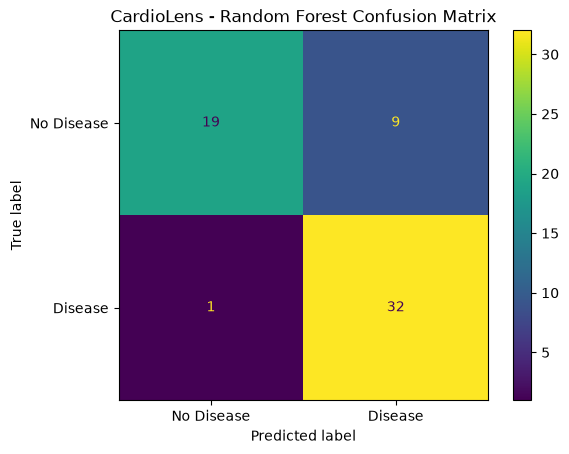

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("CardioLens - Random Forest Confusion Matrix")
plt.show()